# IMDB Rating Prediction
Predicting IMDB ratings using regression models on combined movie data.

## 1. Imports

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast, warnings



warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 2. Load Data

In [2]:
old_df = pd.read_csv('imdb_top_1000.csv')
new_df = pd.read_csv('Top_10000_Movies_IMDb.csv')

print('Old dataset shape:', old_df.shape)
print('New dataset shape:', new_df.shape)

Old dataset shape: (1000, 16)
New dataset shape: (9999, 12)


## 3. Merge & Clean Datasets

In [3]:
# Rename new_df columns to match old_df
new_df = new_df.rename(columns={
    'Movie Name': 'Series_Title',
    'Rating':     'IMDB_Rating',
    'Votes':      'No_of_Votes',
    'Metascore':  'Meta_score',
    'Directors':  'Director'
})

# Director column in new_df is a list string — extract first name
def get_first_director(val):
    try:
        lst = ast.literal_eval(str(val))
        return lst[0] if isinstance(lst, list) else str(val)
    except:
        return str(val)

if 'Director' in new_df.columns:
    new_df['Director'] = new_df['Director'].apply(get_first_director)

# Select common columns
cols = ['Series_Title', 'Runtime', 'Genre', 'IMDB_Rating', 'Meta_score', 'Director', 'No_of_Votes', 'Gross']
old_df = old_df[[c for c in cols if c in old_df.columns]]
new_df = new_df[[c for c in cols if c in new_df.columns]]

# Combine and remove duplicates
df = pd.concat([old_df, new_df], ignore_index=True)
df = df.drop_duplicates(subset=['Series_Title'], keep='first').reset_index(drop=True)

print('Combined dataset shape:', df.shape)
df.head()

Combined dataset shape: (9861, 8)


,Series_Title,Runtime,Genre,IMDB_Rating,Meta_score,Director,No_of_Votes,Gross
0,The Shawshank Redemption,142 min,Drama,9.3,80.0,Frank Darabont,2343110,"28,341,469"
1,The Godfather,175 min,"Crime, Drama",9.2,100.0,Francis Ford Coppola,1620367,"134,966,411"
2,The Dark Knight,152 min,"Action, Crime, Drama",9.0,84.0,Christopher Nolan,2303232,"534,858,444"
3,The Godfather: Part II,202 min,"Crime, Drama",9.0,90.0,Francis Ford Coppola,1129952,"57,300,000"
4,12 Angry Men,96 min,"Crime, Drama",9.0,96.0,Sidney Lumet,689845,"4,360,000"


In [4]:
# Fix data types and fill missing values

df['Runtime']    = pd.to_numeric(df['Runtime'].astype(str).str.replace(' min',''), errors='coerce')
df['No_of_Votes']= pd.to_numeric(df['No_of_Votes'].astype(str).str.replace(',',''), errors='coerce')
df['Gross']      = pd.to_numeric(df['Gross'].astype(str).str.replace(',',''), errors='coerce')
df['Meta_score'] = pd.to_numeric(df['Meta_score'], errors='coerce')
df['IMDB_Rating']= pd.to_numeric(df['IMDB_Rating'], errors='coerce')

df.dropna(subset=['IMDB_Rating'], inplace=True)

for col in ['Runtime', 'No_of_Votes', 'Gross', 'Meta_score']:
    df[col] = df[col].fillna(df[col].median())

df['Director'] = df['Director'].fillna('Unknown')

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
Series_Title    0
Runtime         0
Genre           0
IMDB_Rating     0
Meta_score      0
Director        0
No_of_Votes     0
Gross           0
dtype: int64


## 4. Exploratory Data Analysis

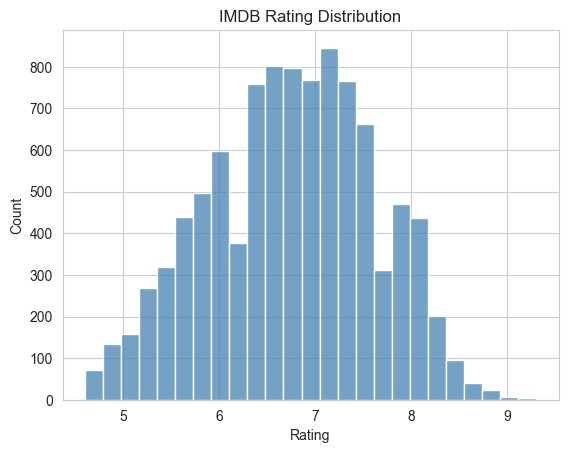

In [5]:
sns.histplot(df['IMDB_Rating'], bins=25, color='steelblue')
plt.title('IMDB Rating Distribution')
plt.xlabel('Rating')
plt.show()

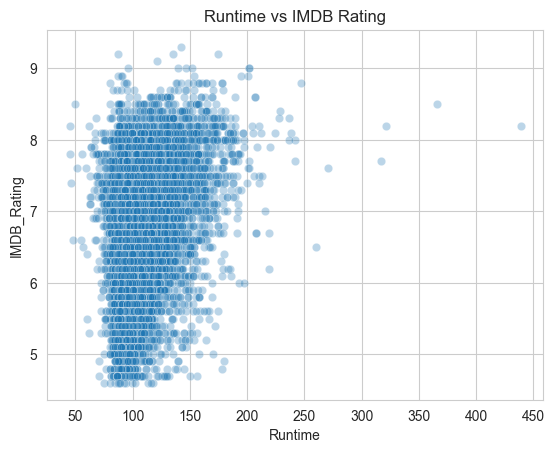

In [6]:
sns.scatterplot(x='Runtime', y='IMDB_Rating', data=df, alpha=0.3)
plt.title('Runtime vs IMDB Rating')
plt.show()

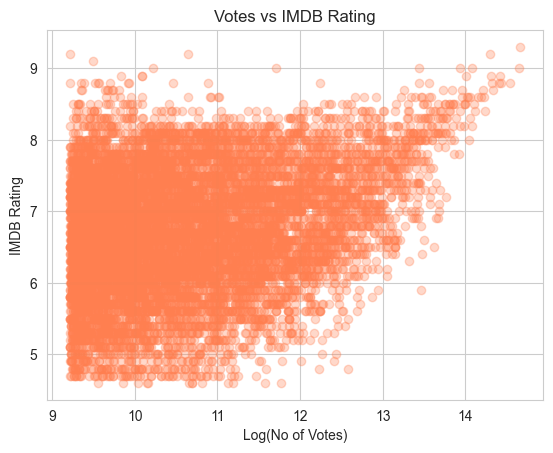

In [7]:
# Votes vs Rating (log scale makes it readable)
plt.scatter(np.log1p(df['No_of_Votes']), df['IMDB_Rating'], alpha=0.3, color='coral')
plt.xlabel('Log(No of Votes)')
plt.ylabel('IMDB Rating')
plt.title('Votes vs IMDB Rating')
plt.show()

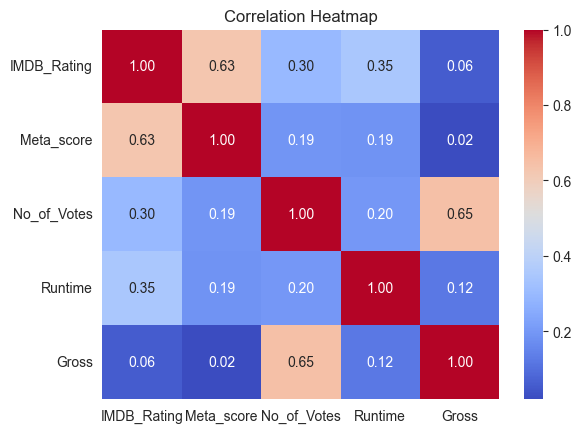

In [8]:
# Correlation heatmap
num_cols = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Runtime', 'Gross']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

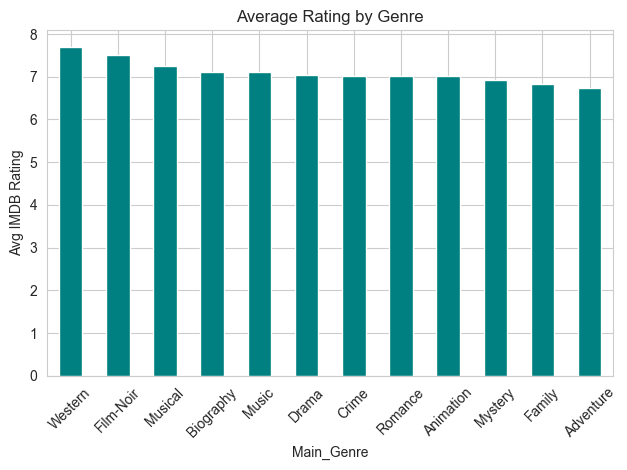

In [9]:
# Average rating by main genre
df['Main_Genre'] = df['Genre'].astype(str).str.split(',').str[0].str.strip()
genre_avg = df.groupby('Main_Genre')['IMDB_Rating'].mean().sort_values(ascending=False).head(12)

genre_avg.plot(kind='bar', color='teal')
plt.title('Average Rating by Genre')
plt.ylabel('Avg IMDB Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

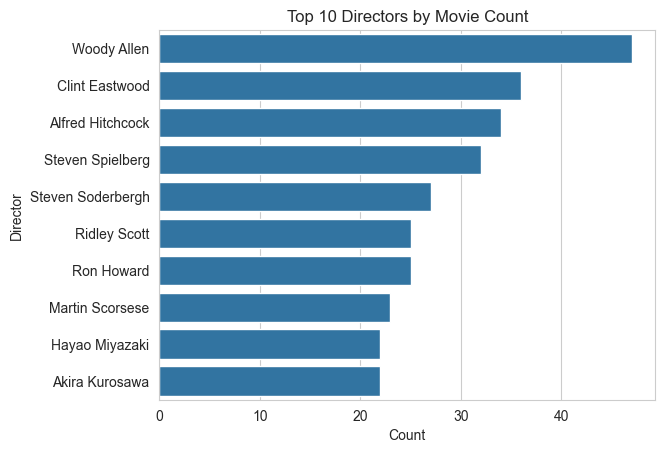

In [10]:
# Top 10 directors by movie count
top_directors = df['Director'].value_counts().head(10)
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title('Top 10 Directors by Movie Count')
plt.xlabel('Count')
plt.show()

## 5. Feature Engineering


In [11]:
# Log transform skewed features
df['Log_Votes'] = np.log1p(df['No_of_Votes'])
df['Log_Gross'] = np.log1p(df['Gross'])

# Director reputation: average rating of all their movies in the dataset
df['Director_Avg_Rating'] = df.groupby('Director')['IMDB_Rating'].transform('mean')

# Genre avg rating
df['Genre_Avg_Rating'] = df.groupby('Main_Genre')['IMDB_Rating'].transform('mean')

print('New features added: Log_Votes, Log_Gross, Director_Avg_Rating, Genre_Avg_Rating')
df[['Log_Votes', 'Log_Gross', 'Director_Avg_Rating', 'Genre_Avg_Rating']].describe()

New features added: Log_Votes, Log_Gross, Director_Avg_Rating, Genre_Avg_Rating


,Log_Votes,Log_Gross,Director_Avg_Rating,Genre_Avg_Rating
count,9861.000000,9861.000000,9861.000000,9861.000000
mean,10.664068,14.319137,6.746740,6.746740
std,1.105295,3.362512,0.706027,0.273554
min,9.210540,2.079442,4.600000,6.075670
25%,9.735128,10.597659,6.300000,6.547072
50%,10.436349,15.265467,6.750000,6.601035
75%,11.401424,17.287477,7.254545,7.034883
max,14.666990,20.657833,9.200000,7.700000


## 6. Train / Test Split

In [12]:
from sklearn.model_selection import train_test_split

features = ['Meta_score', 'Log_Votes', 'Runtime', 'Log_Gross',
            'Director_Avg_Rating', 'Genre_Avg_Rating']

X = df[features]
y = df['IMDB_Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (7888, 6)
Test size : (1973, 6)


## 7. Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on train!
X_test_scaled  = scaler.transform(X_test)

print('Scaling done.')

Scaling done.


## 8. Model Training & Evaluation


### 8.1 Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

print('Linear Regression')
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_lr)), 4))
print('MAE :', round(mean_absolute_error(y_test, pred_lr), 4))
print('R2  :', round(r2_score(y_test, pred_lr), 4))

Linear Regression
RMSE: 0.4347
MAE : 0.3341
R2  : 0.7503


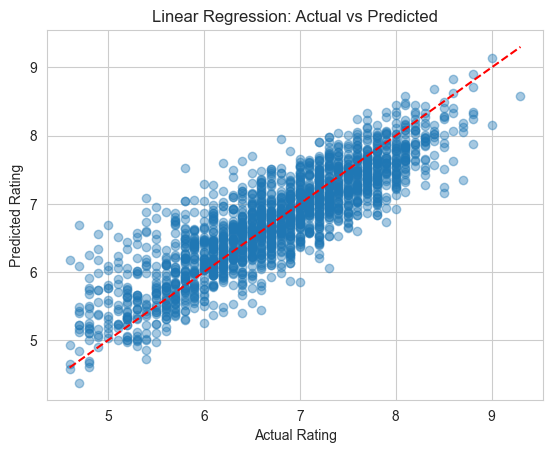

In [15]:
plt.scatter(y_test, pred_lr, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

### 8.2 Ridge Regression

In [16]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)
pred_ridge = ridge.predict(X_test_scaled)

print('Ridge Regression')
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_ridge)), 4))
print('MAE :', round(mean_absolute_error(y_test, pred_ridge), 4))
print('R2  :', round(r2_score(y_test, pred_ridge), 4))

Ridge Regression
RMSE: 0.4347
MAE : 0.3342
R2  : 0.7503


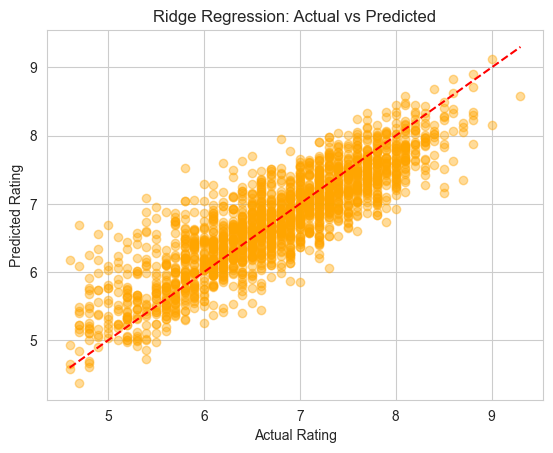

In [17]:
plt.scatter(y_test, pred_ridge, alpha=0.4, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Ridge Regression: Actual vs Predicted')
plt.show()

### 8.3 Lasso Regression

In [18]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
pred_lasso = lasso.predict(X_test_scaled)

print('Lasso Regression')
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_lasso)), 4))
print('MAE :', round(mean_absolute_error(y_test, pred_lasso), 4))
print('R2  :', round(r2_score(y_test, pred_lasso), 4))

Lasso Regression
RMSE: 0.4362
MAE : 0.3343
R2  : 0.7485


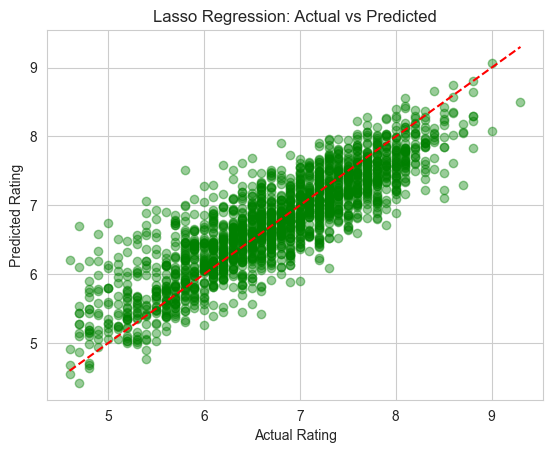

In [19]:
plt.scatter(y_test, pred_lasso, alpha=0.4, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Lasso Regression: Actual vs Predicted')
plt.show()

### 8.4 Random Forest

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=12, 
                           min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)   # RF doesn't need scaling
pred_rf = rf.predict(X_test)

print('Random Forest')
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_rf)), 4))
print('MAE :', round(mean_absolute_error(y_test, pred_rf), 4))
print('R2  :', round(r2_score(y_test, pred_rf), 4))

Random Forest
RMSE: 0.4082
MAE : 0.3003
R2  : 0.7797


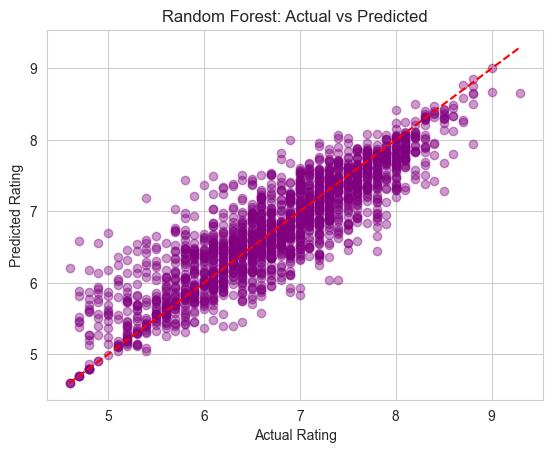

In [21]:
plt.scatter(y_test, pred_rf, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

### 8.5 Tuned Random Forest (GridSearchCV)

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [8, 12, None],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                       param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
pred_best_rf = best_rf.predict(X_test)

print('Best params:', grid_rf.best_params_)
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_best_rf)), 4))
print('MAE :', round(mean_absolute_error(y_test, pred_best_rf), 4))
print('R2  :', round(r2_score(y_test, pred_best_rf), 4))

Best params: {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 200}
RMSE: 0.4082
MAE : 0.3003
R2  : 0.7797


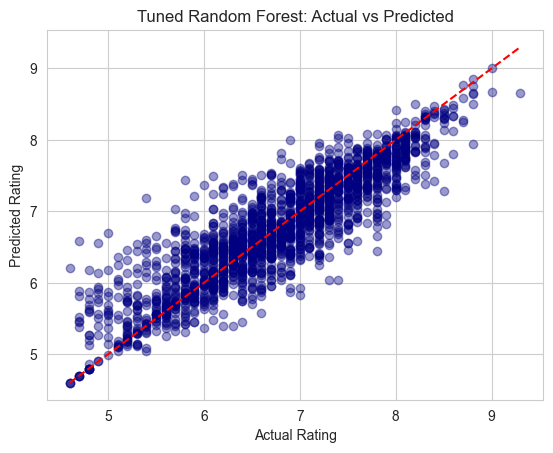

In [23]:
plt.scatter(y_test, pred_best_rf, alpha=0.4, color='navy')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Tuned Random Forest: Actual vs Predicted')
plt.show()

### 8.6 Gradient Boosting

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                 max_depth=4, subsample=0.8, random_state=42)
gbr.fit(X_train, y_train)
pred_gbr = gbr.predict(X_test)

print('Gradient Boosting')
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_gbr)), 4))
print('MAE :', round(mean_absolute_error(y_test, pred_gbr), 4))
print('R2  :', round(r2_score(y_test, pred_gbr), 4))

Gradient Boosting
RMSE: 0.4032
MAE : 0.2978
R2  : 0.7851


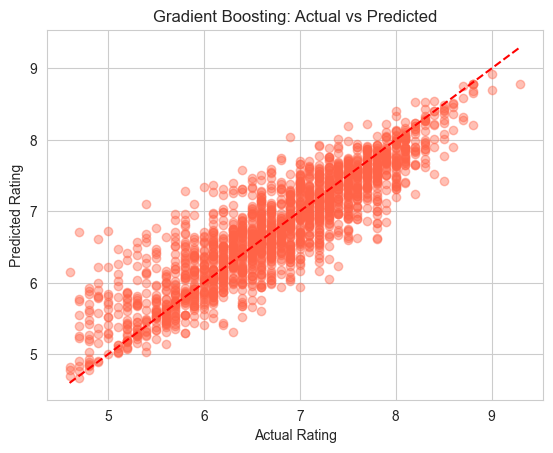

In [25]:
plt.scatter(y_test, pred_gbr, alpha=0.4, color='tomato')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Gradient Boosting: Actual vs Predicted')
plt.show()

### 8.7 Tuned Gradient Boosting

In [26]:
param_grid_gbr = {
    'n_estimators':  [200, 300],
    'learning_rate': [0.03, 0.05],
    'max_depth':     [3, 4, 5]
}

grid_gbr = GridSearchCV(GradientBoostingRegressor(random_state=42),
                        param_grid_gbr, cv=3, scoring='r2', n_jobs=-1)
grid_gbr.fit(X_train, y_train)

best_gbr = grid_gbr.best_estimator_
pred_best_gbr = best_gbr.predict(X_test)

print('Best params:', grid_gbr.best_params_)
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_best_gbr)), 4))
print('MAE :', round(mean_absolute_error(y_test, pred_best_gbr), 4))
print('R2  :', round(r2_score(y_test, pred_best_gbr), 4))

Best params: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300}
RMSE: 0.4075
MAE : 0.3019
R2  : 0.7805


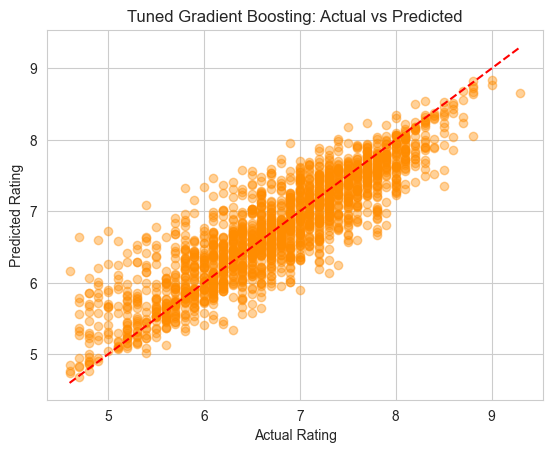

In [27]:
plt.scatter(y_test, pred_best_gbr, alpha=0.4, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Tuned Gradient Boosting: Actual vs Predicted')
plt.show()

### 8.8 Combined Model (RF + GBR average)
Same idea as your original — average predictions of best RF and best GBR.

In [28]:
pred_combined = (pred_best_rf + pred_best_gbr) / 2

print('Combined Model (RF + GBR average)')
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_combined)), 4))
print('MAE :', round(mean_absolute_error(y_test, pred_combined), 4))
print('R2  :', round(r2_score(y_test, pred_combined), 4))

Combined Model (RF + GBR average)
RMSE: 0.405
MAE : 0.2987
R2  : 0.7832


## 9. Feature Importance (Gradient Boosting)

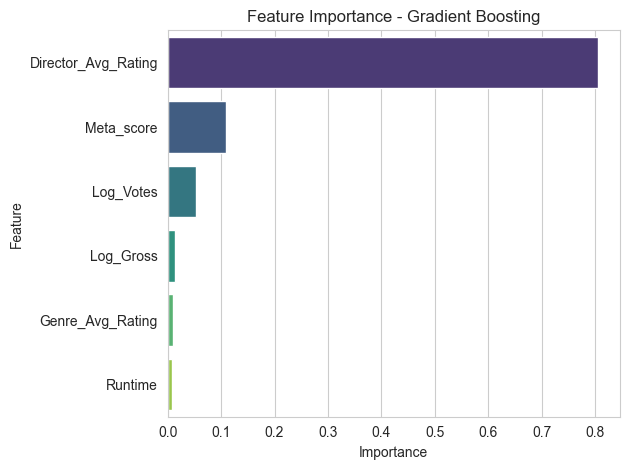

In [29]:
fi = pd.DataFrame({'Feature': features, 'Importance': best_gbr.feature_importances_})
fi = fi.sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=fi, palette='viridis')
plt.title('Feature Importance - Gradient Boosting')
plt.tight_layout()
plt.show()

## 10. Model Comparison

In [30]:
results = pd.DataFrame([
    {'Model': 'Linear Regression',      'R2': r2_score(y_test, pred_lr),       'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr))},
    {'Model': 'Ridge Regression',       'R2': r2_score(y_test, pred_ridge),     'RMSE': np.sqrt(mean_squared_error(y_test, pred_ridge))},
    {'Model': 'Lasso Regression',       'R2': r2_score(y_test, pred_lasso),     'RMSE': np.sqrt(mean_squared_error(y_test, pred_lasso))},
    {'Model': 'Random Forest',          'R2': r2_score(y_test, pred_rf),        'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf))},
    {'Model': 'Tuned Random Forest',    'R2': r2_score(y_test, pred_best_rf),   'RMSE': np.sqrt(mean_squared_error(y_test, pred_best_rf))},
    {'Model': 'Gradient Boosting',      'R2': r2_score(y_test, pred_gbr),       'RMSE': np.sqrt(mean_squared_error(y_test, pred_gbr))},
    {'Model': 'Tuned Gradient Boosting','R2': r2_score(y_test, pred_best_gbr),  'RMSE': np.sqrt(mean_squared_error(y_test, pred_best_gbr))},
    {'Model': 'Combined (RF + GBR)',    'R2': r2_score(y_test, pred_combined),  'RMSE': np.sqrt(mean_squared_error(y_test, pred_combined))},
])

results = results.sort_values('R2', ascending=False).round(4)
print(results.to_string(index=False))

                  Model     R2   RMSE
      Gradient Boosting 0.7851 0.4032
    Combined (RF + GBR) 0.7832 0.4050
Tuned Gradient Boosting 0.7805 0.4075
          Random Forest 0.7797 0.4082
    Tuned Random Forest 0.7797 0.4082
       Ridge Regression 0.7503 0.4347
      Linear Regression 0.7503 0.4347
       Lasso Regression 0.7485 0.4362


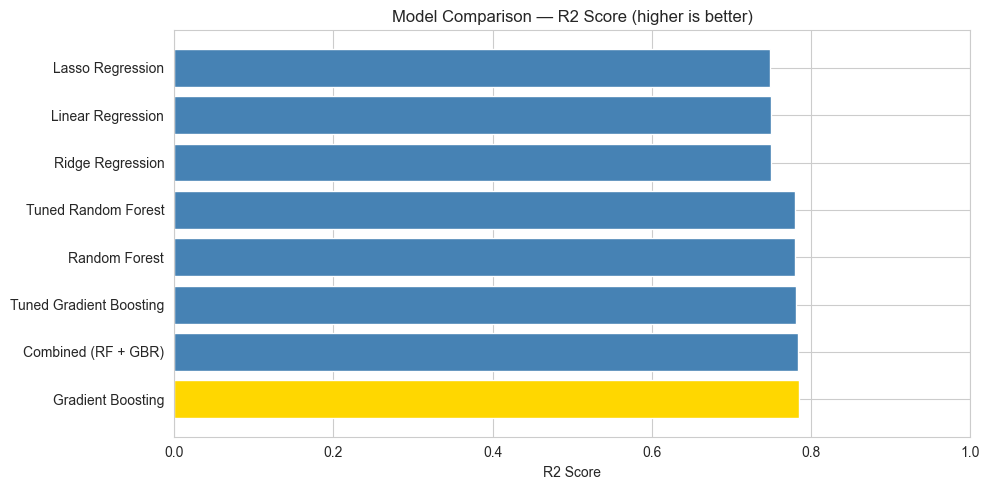

In [31]:
plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results))]
plt.barh(results['Model'], results['R2'], color=colors)
plt.xlabel('R2 Score')
plt.title('Model Comparison — R2 Score (higher is better)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 11. Error Analysis

In [37]:
# Using best model predictions
best_preds = pred_best_gbr

comparison = pd.DataFrame({
    'Actual Rating':    y_test.values,
    'Predicted Rating': best_preds,
    'Error':            abs(y_test.values - best_preds)
})

print('Average Error:', round(comparison['Error'].mean(), 3))
print('Maximum Error:', round(comparison['Error'].max(), 3))
print('Minimum Error:', round(comparison['Error'].min(), 3))

comparison.head(1000)

Average Error: 0.302
Maximum Error: 1.935
Minimum Error: 0.0


,Actual Rating,Predicted Rating,Error
0,6.5,7.032495,0.532495
1,7.9,7.759651,0.140349
2,6.1,6.539650,0.439650
3,7.7,7.655666,0.044334
4,6.7,6.540728,0.159272
...,...,...,...
995,5.8,5.780288,0.019712
996,6.8,6.834204,0.034204
997,6.1,6.381344,0.281344
998,5.8,6.348944,0.548944


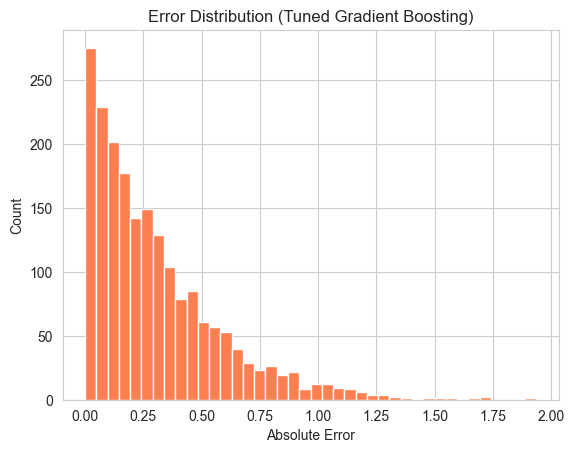

In [38]:
plt.hist(comparison['Error'], bins=40, color='coral', edgecolor='white')
plt.xlabel('Absolute Error')
plt.ylabel('Count')
plt.title('Error Distribution (Tuned Gradient Boosting)')
plt.show()

## 12. Prediction Function

In [39]:
def predict_imdb_rating(meta_score, no_of_votes, runtime, gross=0, director=None, genre='Drama'):
    """
    Predict IMDB rating for a new movie.
    meta_score  : Metacritic score (0-100)
    no_of_votes : Number of IMDB votes
    runtime     : Runtime in minutes
    gross       : Box office gross in USD (0 if unknown)
    director    : Director name (optional)
    genre       : Main genre (e.g. 'Drama', 'Action')
    """
    # Director avg rating
    if director and director in df['Director'].values:
        dir_avg = df[df['Director'] == director]['IMDB_Rating'].mean()
    else:
        dir_avg = df['Director_Avg_Rating'].mean()

    # Genre avg rating
    genre_avg = df[df['Main_Genre'] == genre]['IMDB_Rating'].mean()
    if pd.isna(genre_avg):
        genre_avg = df['Genre_Avg_Rating'].mean()

    inp = pd.DataFrame([{
        'Meta_score':          meta_score,
        'Log_Votes':           np.log1p(no_of_votes),
        'Runtime':             runtime,
        'Log_Gross':           np.log1p(gross),
        'Director_Avg_Rating': dir_avg,
        'Genre_Avg_Rating':    genre_avg
    }])

    rating = float(np.clip(best_gbr.predict(inp)[0], 1.0, 10.0))
    print(f'Predicted IMDB Rating: {rating:.2f} / 10')
    return round(rating, 2)

In [35]:
# Example: a high budget action movie by Christopher Nolan
predict_imdb_rating(
    meta_score=85,
    no_of_votes=800000,
    runtime=150,
    gross=500000000,
    director='Christopher Nolan',
    genre='Action'
)

Predicted IMDB Rating: 8.12 / 10


8.12

In [36]:
# Example: a small drama film
predict_imdb_rating(
    meta_score=60,
    no_of_votes=20000,
    runtime=95,
    gross=1000000,
    genre='Drama'
)

Predicted IMDB Rating: 6.66 / 10


6.66